In [75]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import requests
from io import BytesIO
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 10000 files belonging to 10 classes.


In [3]:
val_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 1000 files belonging to 10 classes.


In [4]:
conv_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3), pooling='avg')
conv_base.trainable = False

In [6]:
def extract_features(data):
    features = []
    labels = []
    for images, label in data:
        try :
            feature_batch = conv_base.predict(images)
            features.append(feature_batch)
            labels.append(label)
        except Exception as e:
            print(f"Error occurred while processing {images.file_path}: {e}")
            continue
    return np.vstack(features), np.vstack(labels)

In [7]:
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [8]:
print("Sample train features (first 5 rows):", train_features[:5])
print("Sample train labels (first 5):", train_labels[:5])
print("Sample validation features (first 5 rows):", val_features[:5])
print("Sample validation labels (first 5):", val_labels[:5])

Sample train features (first 5 rows): [[4.2458612e-04 4.1319132e-03 5.0510820e-03 ... 1.5806363e+00
  2.1623680e-01 7.4743247e-01]
 [2.9030509e-04 3.7360115e-03 3.1837667e-03 ... 1.5569746e+00
  8.1528991e-02 1.0785909e-02]
 [3.6713772e-04 4.1792872e-03 5.0997115e-03 ... 1.9934937e+00
  7.3268348e-01 1.4719837e+00]
 [4.1596100e-04 6.0199415e-03 4.6675275e-03 ... 1.5444361e+00
  3.6721915e-01 8.5781395e-01]
 [3.3886399e-04 5.2885567e-03 3.5725930e-03 ... 4.0248771e+00
  5.7893920e-01 1.3050054e-01]]
Sample train labels (first 5): [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Sample validation features (first 5 rows): [[3.5330467e-04 4.7577512e-03 4.1107135e-03 ... 2.9630740e+00
  2.4129142e-01 1.2260826e+00]
 [2.1067774e-04 3.8270229e-03 4.2384025e-03 ... 1.6281561e+00
  1.3667539e-01 1.0031417e-03]
 [3.0457988e-04 3.9451262e-03 2.3113028e-03 ... 3.4717159e+00
  4.6724

# Flatten labels for compatibility


In [9]:
train_labels = np.argmax(train_labels, axis=1)
val_labels = np.argmax(val_labels, axis=1)

In [10]:
print(train_data)
print(val_data)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>


# Train Random Forest Classifier


In [12]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(train_features, train_labels)

RandomForestClassifier(n_estimators=200, random_state=42)

In [127]:
rf_predictions = rf_classifier.predict(val_features)
random_forest_accuracy = accuracy_score(val_labels, rf_predictions)  * 100
print("Random Forest Accuracy:", accuracy_score(val_labels, rf_predictions) * 100)
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(val_labels, rf_predictions))

Random Forest Accuracy: 89.0
Confusion Matrix (Random Forest):
[[ 96   2   0   0   0   0   0   2   0   0]
 [  1  86   3   1   3   3   2   0   1   0]
 [  1  12  82   1   2   0   2   0   0   0]
 [  0   2   0  89   1   4   3   0   1   0]
 [  3   5   4   1  85   0   2   0   0   0]
 [  0   0   0   5   0  88   5   0   1   1]
 [  1   1   0   0   5  10  76   0   1   6]
 [  3   0   0   0   1   1   0  95   0   0]
 [  0   0   0   0   0   0   0   0 100   0]
 [  0   0   0   0   0   0   6   0   1  93]]


# Simple CNN

In [15]:
def create_simple_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

## Training the model with 5 epoch

In [16]:
simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.fit(train_data, epochs=5, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/5


c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 240s 759ms/step - accuracy: 0.5683 - loss: 1.8002 - val_accuracy: 0.1000 - val_loss: 16.1463
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 242s 772ms/step - accuracy: 0.8071 - loss: 0.6187 - val_accuracy: 0.6960 - val_loss: 1.0240
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 252s 804ms/step - accuracy: 0.8601 - loss: 0.4286 - val_accuracy: 0.8510 - val_loss: 0.5321
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 235s 750ms/step - accuracy: 0.9001 - loss: 0.3040 - val_accuracy: 0.8200 - val_loss: 0.8048
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 774ms/step - accuracy: 0.9172 - loss: 0.2512 - val_accuracy: 0.8780 - val_loss: 0.5310


In [128]:
simple_cnn_eval = simple_cnn.evaluate(val_data)
simple_cnn_accuracy = simple_cnn_eval[1] * 100
print("Simple CNN Accuracy:", simple_cnn_eval[1] * 100)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.8282 - loss: 0.6797
Simple CNN Accuracy: 84.60000157356262


In [24]:
def create_densenet_cnn():
    model = Sequential([
        conv_base,
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.35),
        BatchNormalization(),
        Dense(120, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [130]:
densenet_cnn = create_densenet_cnn()
densenet_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
densenet_cnn.fit(train_data, epochs=5, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/5


313/313 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.3691 - loss: 1.8658 - val_accuracy: 0.7800 - val_loss: 0.8671
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.7557 - loss: 0.7782 - val_accuracy: 0.8470 - val_loss: 0.5122
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.8377 - loss: 0.5293 - val_accuracy: 0.8700 - val_loss: 0.3901
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.8689 - loss: 0.4169 - val_accuracy: 0.8860 - val_loss: 0.3293
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.8917 - loss: 0.3328 - val_accuracy: 0.9060 - val_loss: 0.2861


In [131]:
densenet_cnn_eval = densenet_cnn.evaluate(val_data)
print("DenseNet CNN Accuracy:", densenet_cnn_eval[1] * 100)
densenet_cnn_accuracy = densenet_cnn_eval[1] * 100

32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8999 - loss: 0.3064
DenseNet CNN Accuracy: 90.6000018119812


In [132]:
def predict_from_url(url, model, model_type='densenet'):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    if model_type == 'rf':
        # Random Forest Model expects the features extracted via DenseNet
        features = conv_base.predict(img_array)
        prediction = model.predict(features)
        predicted_label = np.argmax(prediction)
    elif model_type == 'simple_cnn':
        # Simple CNN directly predicts from the image
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)
    elif model_type == 'densenet':
        # DenseNet-based CNN directly predicts from the image
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)

    return predicted_label

In [154]:
class_labels = [
    "Bacterial Spot", 
    "Early Blight",   
    "Healthy",   
    "Late Blight",
    "Leaf Mold",
    "Septoria leaf spot",
    "Two Spotted Spider mite",
    "Target spot",
    "mosaic virus",
    "yellow leaf virus"
]

In [155]:
example_url = "https://media.istockphoto.com/id/1265081175/photo/manifestations-of-late-blight-on-tomato-leaves-fungal-disease-of-tomatoes.jpg?s=612x612&w=0&k=20&c=X6yL4cuokdMg4-Iod6s-L_ZTUZ9tskwkEFD5Rfkx3NI="
predicted_rf_disease = predict_from_url(example_url, rf_classifier, model_type='rf')
predicted_simple_cnn_disease = predict_from_url(example_url, simple_cnn, model_type='simple_cnn')
predicted_densenet_disease = predict_from_url(example_url, densenet_cnn, model_type='densenet')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


In [156]:
predicted_rf_disease_name = class_labels[predicted_rf_disease]
predicted_simple_cnn_disease_name = class_labels[predicted_simple_cnn_disease]
predicted_densenet_disease_name = class_labels[predicted_densenet_disease]

In [157]:
print("Predicted Disease Label (Random Forest):", predicted_rf_disease_name)
print("Predicted Disease Label (Simple CNN):", predicted_simple_cnn_disease_name)
print("Predicted Disease Label (DenseNet CNN):", predicted_densenet_disease_name)

Predicted Disease Label (Random Forest): Bacterial Spot
Predicted Disease Label (Simple CNN): Early Blight
Predicted Disease Label (DenseNet CNN): Healthy


C:\Users\tiger\AppData\Local\Temp\ipykernel_31420\3238778116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')


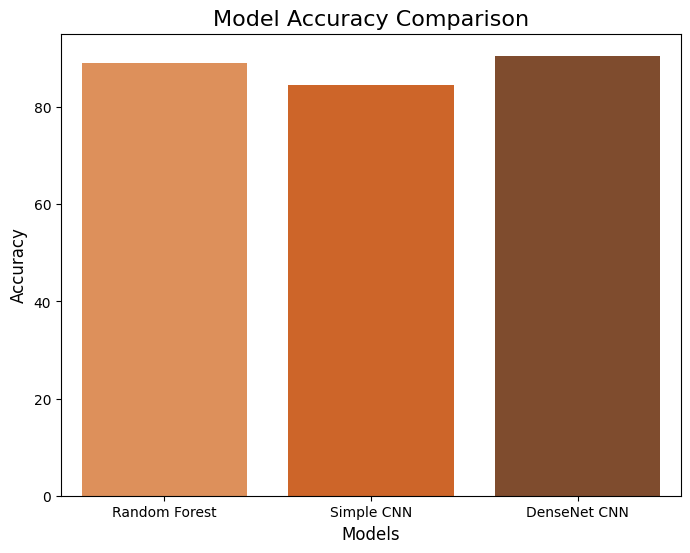

In [158]:
model_names = ['Random Forest', 'Simple CNN', 'DenseNet CNN']
accuracies = [random_forest_accuracy, simple_cnn_accuracy, densenet_cnn_accuracy]  # Replace with actual accuracy values

# Create a bar plot for model accuracies
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Show the plot
plt.show()

In [159]:
densenet_predictions = np.argmax(densenet_cnn.predict(val_data), axis=1)
simple_cnn_predictions = np.argmax(simple_cnn.predict(val_data), axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step


In [160]:
densenet_cm = confusion_matrix(val_labels, densenet_predictions)
print(densenet_cm)

[[12 10 12  6 11 12  7  8 12 10]
 [11 14  8  9  8  7 11  8 14 10]
 [ 9 13  9 10  9  8  7 14 10 11]
 [ 7 14 14  5  8  9 18  6 10  9]
 [12  8 17  8 12 11  4  5  8 15]
 [11  9 16  9 13  8  7 11  8  8]
 [14  4 12 13 10 10  9  9 13  6]
 [12  4  8 11  7 16  7 10 12 13]
 [ 7  6 10 10  5 12 11 14 13 12]
 [ 9 14  8  9  9 10  8 14  8 11]]


In [161]:
simple_cnn_cm = confusion_matrix(val_labels, simple_cnn_predictions)
print(simple_cnn_cm)

[[11 11 15  2 16  9  6 11  9 10]
 [12 15  6  5 13 15 10 10  8  6]
 [ 9 12  9 11 11 14 12  8 11  3]
 [14  8  9  5 14 10  8  7 12 13]
 [ 7 12  9  6  9 14  8 13  8 14]
 [11 19  7  8 13 13  5 10  7  7]
 [ 9  7 11 11  8 12  6 10 12 14]
 [ 6 13 11  3 13 13 11 11  9 10]
 [ 6 13 12  5 10 12 11 13 11  7]
 [ 8 13 10  3 11 12  7  9 15 12]]


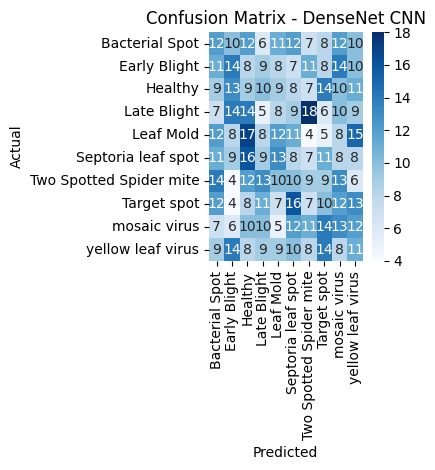

In [165]:
plt.subplot(1, 2, 1)
sns.heatmap(densenet_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DenseNet CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

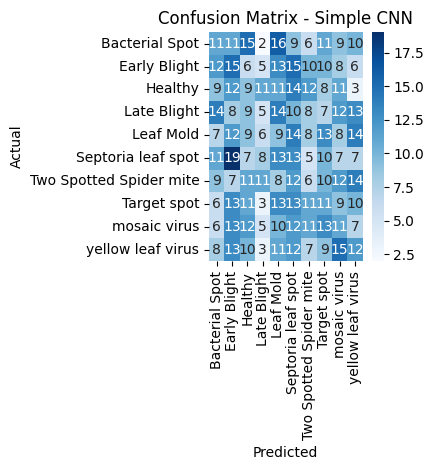

In [166]:
plt.subplot(1, 2, 2)
sns.heatmap(simple_cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Simple CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()